# Chapter 6. Symmetric Spaces of the Noncompact Type

**Source Span.** Helgason, *Differential Geometry, Lie Groups, and Symmetric Spaces*, Chapter VI, printed pages 252-280 (approximately PDF pages 279-307).

**Chapter Goal.** Build the noncompact symmetric-space toolkit: Cartan decomposition, maximal compact subgroups, Iwasawa decomposition `G = KAN`, nilpotent exponential coordinates, solvable `AN` models, and the complex-case version.

**Translation guide.**

- A noncompact symmetric pair starts from a Cartan decomposition `g0 = k0 + p0`; the Cartan involution makes `ad X` symmetric for `X in p0` and `ad T` skew for `T in k0`.
- The map `(X,k) -> exp(X)k` is the group-level polar decomposition; it makes `G/K` diffeomorphic to the vector space `p0`.
- Negative curvature geometry forces compact subgroups to fix points, hence maximal compact subgroups are conjugate.
- Iwasawa decomposition refines the group into `K A N`, where `A` is abelian and `N` is nilpotent.
- Nilpotent groups have polynomial multiplication in exponential coordinates; the Heisenberg group is the smallest useful witness.
- The solvable group `AN` acts simply transitively on `G/K`; in rank one this gives explicit upper-half-plane coordinates.
- For complex semisimple algebras viewed as real, the decomposition simplifies to `g_R = u + J a + n+`, with restricted root multiplicity doubled.


## Visual Storyboard and Library Routing

| Source block | Representation | Library route | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| Section 1: Cartan decomposition | `SL(2,R)/SO(2)` polar/Exp coordinate view | SymPy + NumPy + Matplotlib | `p0` maps to upper-half-plane points and `Be` has symmetric/skew adjoints | determinant, positivity, adjoint symmetry |
| Section 2: maximal compact conjugacy | Poincare disk fixed-point sketch | Matplotlib | compact subgroups fix a point, then conjugate into the base isotropy | disk automorphism checks |
| Section 3: Iwasawa algebra | `sl(2,R)=k+a+n` and `SL(2,R)=KAN` QR formulas | SymPy + NumPy + Matplotlib | `K`, `A`, and `N` coordinates separately control angle, height, and horocycle | reconstruction residuals |
| Section 3: restricted roots | split `sl(3,R)` positive roots and nilpotent `n` | SymPy + Matplotlib | upper triangular root spaces form nilpotent `n` | bracket and central-series checks |
| Section 4: nilpotent Lie groups | Heisenberg BCH polynomial | SymPy + Matplotlib | central correction records signed area | associativity and polynomial checks |
| Section 5: global decompositions | `AN -> P` via `theta(s)s^-1` | NumPy + Matplotlib | solvable coordinates parametrize positive symmetric matrices | symmetry, determinant, eigenvalue checks |
| Section 6: complex case | `sl(2,C)_R = su(2) + J a + n+` dimension/multiplicity table | SymPy + Matplotlib | complex root space becomes real dimension two | dimension and multiplicity checks |

Matplotlib gives durable static diagrams for validation; SymPy supplies exact bracket checks; NumPy handles concrete matrix decompositions.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import networkx as nx
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Helgason book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-06-symmetric-spaces-of-the-noncompact-type"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

artifact_paths = []
chapter_checks = {}

def record(path: Path) -> Path:
    artifact_paths.append(Path(path))
    return Path(path)

def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def comm(A: sp.Matrix, B: sp.Matrix) -> sp.Matrix:
    return sp.simplify(A * B - B * A)

def mobius(matrix: np.ndarray, z: complex) -> complex:
    a, b, c, d = matrix[0, 0], matrix[0, 1], matrix[1, 0], matrix[1, 1]
    return (a * z + b) / (c * z + d)

def exp_sl2_symmetric(a: float, b: float) -> np.ndarray:
    X = np.array([[a, b], [b, -a]], dtype=float)
    r = float(np.hypot(a, b))
    if r < 1e-12:
        return np.eye(2) + X
    return math.cosh(r) * np.eye(2) + (math.sinh(r) / r) * X

print(f"Artifacts will be written under {rel(ARTIFACT_ROOT)}")


Artifacts will be written under artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type


In [2]:
storyboard = [
    {"source_sections": "1. Decomposition of a semisimple Lie group", "concept": "Cartan polar decomposition and Exp diffeomorphism", "artifact": "figures/cartan_exp_upper_half_plane.png", "validation": "Be adjoint checks and upper-half-plane positivity"},
    {"source_sections": "2. Maximal compact subgroups", "concept": "fixed point and conjugacy into K", "artifact": "figures/maximal_compact_fixed_point_conjugacy.png", "validation": "disk automorphisms move fixed points to the origin"},
    {"source_sections": "3. Iwasawa decomposition", "concept": "SL(2,R)=KAN", "artifact": "figures/sl2_iwasawa_upper_half_plane_coordinates.png", "validation": "QR-style reconstruction residuals"},
    {"source_sections": "3. Restricted roots", "concept": "split sl3 positive roots and nilpotent n", "artifact": "figures/sl3_restricted_roots_and_nilpotent_n.png", "validation": "root brackets and central descending series"},
    {"source_sections": "4. Nilpotent Lie groups", "concept": "Heisenberg BCH polynomial", "artifact": "figures/heisenberg_bch_central_area.png", "validation": "polynomial group law and associativity"},
    {"source_sections": "5. Global decompositions", "concept": "AN coordinates and theta(s)s^-1 into P", "artifact": "figures/an_to_positive_symmetric_matrices.png", "validation": "positive symmetric determinant-one checks"},
    {"source_sections": "6. The complex case", "concept": "complex Iwasawa dimension split", "artifact": "figures/complex_case_root_multiplicity.png", "validation": "sl2C_R dimensions and multiplicity two"},
]
storyboard_path = record(save_json(storyboard, CHECKS / "chapter_06_visual_storyboard.json"))
coverage_path = record(save_csv(storyboard, TABLES / "chapter_06_coverage_map.csv"))
chapter_checks["storyboard_covers_sections_1_to_6"] = all(any(str(i) in item["source_sections"] for item in storyboard) for i in range(1, 7))
print(json.dumps({"storyboard": rel(storyboard_path), "coverage": rel(coverage_path), "items": len(storyboard)}, indent=2))
display_artifact(coverage_path)


{
  "storyboard": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/chapter_06_visual_storyboard.json",
  "coverage": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/chapter_06_coverage_map.csv",
  "items": 7
}


[chapter_06_coverage_map.csv](artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/chapter_06_coverage_map.csv)

## 1. Cartan Decomposition and the Noncompact Exp Map

In noncompact type, the Cartan decomposition `g0 = k0 + p0` is not just a linear split. The group map `(X,k) -> exp(X)k` is a global diffeomorphism, and `Exp : p0 -> G/K` is a diffeomorphism. For `SL(2,R)/SO(2)`, `p0` is the plane of symmetric trace-zero matrices, and `exp(X)` sends the base point `i` in the upper half-plane to a visible point.


{
  "figure": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/figures/cartan_exp_upper_half_plane.png",
  "table": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/cartan_decomposition_exp_checks.csv",
  "checks": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/cartan_decomposition_exp_checks.json"
}


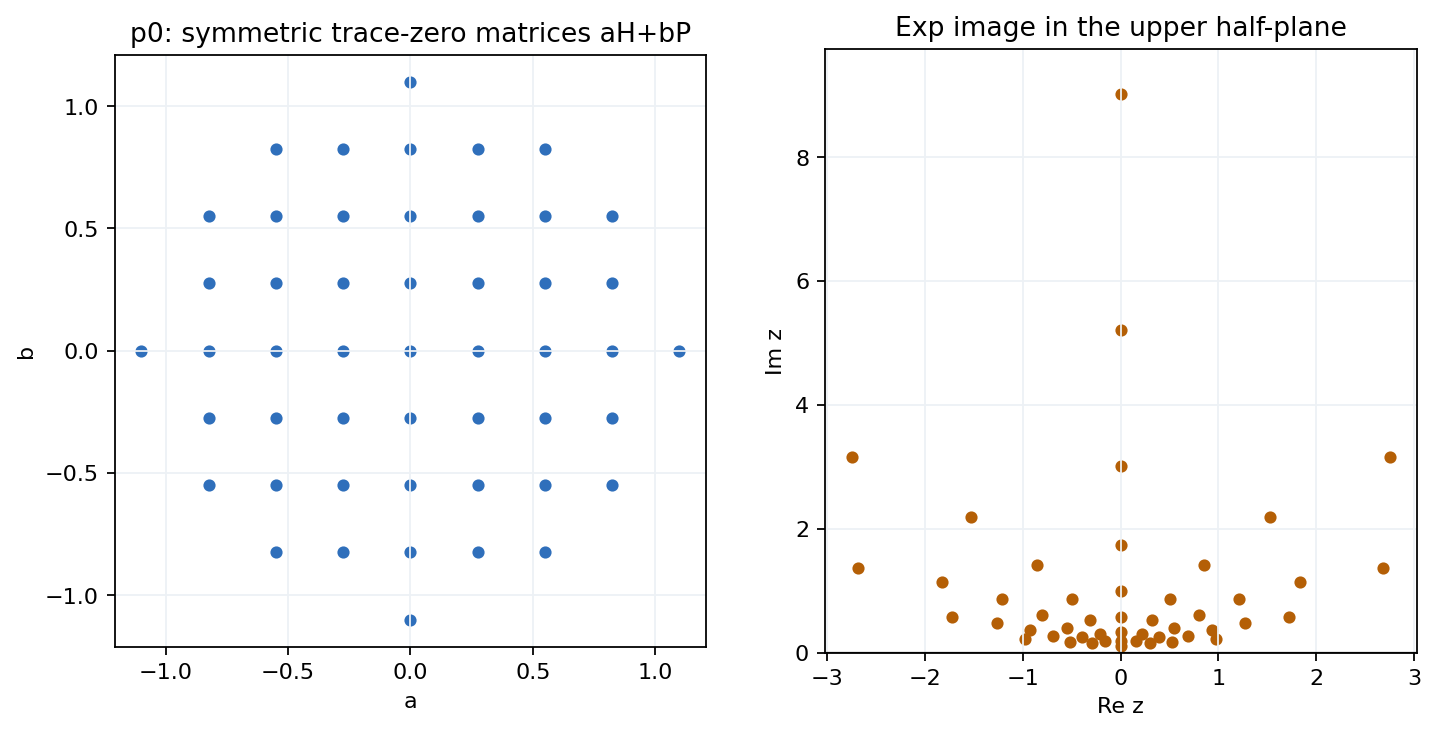

In [3]:
K = sp.Matrix([[0, 1], [-1, 0]])
H = sp.Matrix([[1, 0], [0, -1]])
P = sp.Matrix([[0, 1], [1, 0]])
E = sp.Matrix([[0, 1], [0, 0]])

basis = [K, H, P]
basis_names = ["K", "H", "P"]

def theta_lie(A: sp.Matrix) -> sp.Matrix:
    return -A.T

def B_sl2(A: sp.Matrix, B: sp.Matrix) -> sp.Expr:
    return sp.simplify(4 * sp.trace(A * B))

def Be(A: sp.Matrix, B: sp.Matrix) -> sp.Expr:
    return sp.simplify(-B_sl2(A, theta_lie(B)))

def ad_matrix(X: sp.Matrix) -> sp.Matrix:
    cols = []
    for Y in basis:
        C = comm(X, Y)
        a, b, c = sp.symbols("a b c")
        sol = sp.solve(sp.Eq(C, a * K + b * H + c * P), (a, b, c), dict=True)[0]
        cols.append([sol[a], sol[b], sol[c]])
    return sp.Matrix(cols).T

G_metric = sp.Matrix([[Be(A, B) for B in basis] for A in basis])
ad_H = ad_matrix(H)
ad_P = ad_matrix(P)
ad_K = ad_matrix(K)
cartan_checks = {
    "theta_square_identity_on_basis": all(theta_lie(theta_lie(A)) == A for A in basis),
    "k_p_brackets_land_correctly": bool(comm(K, H) == -2 * P and comm(K, P) == 2 * H and comm(H, P) == 2 * K),
    "ad_H_symmetric_for_Be": bool(ad_H.T * G_metric == G_metric * ad_H),
    "ad_P_symmetric_for_Be": bool(ad_P.T * G_metric == G_metric * ad_P),
    "ad_K_skew_for_Be": bool(ad_K.T * G_metric == -G_metric * ad_K),
}

grid = np.linspace(-1.1, 1.1, 9)
points_p = []
points_h = []
for a in grid:
    for b in grid:
        if a * a + b * b <= 1.25:
            g = exp_sl2_symmetric(float(a), float(b))
            z = mobius(g, 1j)
            points_p.append((a, b))
            points_h.append((z.real, z.imag))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.9))
axes[0].scatter([p[0] for p in points_p], [p[1] for p in points_p], s=20, color="#2f6fbb")
axes[0].set_title("p0: symmetric trace-zero matrices aH+bP")
axes[0].set_xlabel("a")
axes[0].set_ylabel("b")
axes[0].set_aspect("equal")
axes[0].grid(True, color="#edf1f5")
axes[1].scatter([p[0] for p in points_h], [p[1] for p in points_h], s=20, color="#b45f06")
axes[1].axhline(0, color="#222222", linewidth=1)
axes[1].set_title("Exp image in the upper half-plane")
axes[1].set_xlabel("Re z")
axes[1].set_ylabel("Im z")
axes[1].set_ylim(0, max(y for _, y in points_h) * 1.08)
axes[1].grid(True, color="#edf1f5")
cartan_fig = record(save_matplotlib(fig, FIGURES / "cartan_exp_upper_half_plane.png"))
plt.close(fig)

cartan_rows = [
    {"object": "theta on Lie algebra", "check": "theta^2=id", "holds": cartan_checks["theta_square_identity_on_basis"]},
    {"object": "ad H and ad P", "check": "symmetric for Be", "holds": cartan_checks["ad_H_symmetric_for_Be"] and cartan_checks["ad_P_symmetric_for_Be"]},
    {"object": "ad K", "check": "skew for Be", "holds": cartan_checks["ad_K_skew_for_Be"]},
    {"object": "Exp(p0).i", "check": "imaginary part positive", "holds": bool(min(y for _, y in points_h) > 0)},
]
cartan_table = record(save_csv(cartan_rows, TABLES / "cartan_decomposition_exp_checks.csv"))
cartan_report = record(save_json(cartan_checks | {"upper_half_plane_points_positive": bool(min(y for _, y in points_h) > 0)}, CHECKS / "cartan_decomposition_exp_checks.json"))
chapter_checks["cartan_decomposition_checks"] = all(cartan_checks.values()) and min(y for _, y in points_h) > 0
print(json.dumps({"figure": rel(cartan_fig), "table": rel(cartan_table), "checks": rel(cartan_report)}, indent=2))
display_artifact(cartan_fig)


## 2. Maximal Compact Subgroups as Fixed-Point Isotropy

The conjugacy theorem for maximal compact subgroups is geometric: a compact group of isometries of a complete simply connected negatively curved space fixes a point. Moving that point to the base point conjugates the compact group into `K`. The disk sketch below uses automorphisms of the Poincare disk only as a visible fixed-point model.


{
  "figure": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/figures/maximal_compact_fixed_point_conjugacy.png",
  "table": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/maximal_compact_fixed_point_conjugacy.csv",
  "checks": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/maximal_compact_fixed_point_conjugacy_checks.json"
}


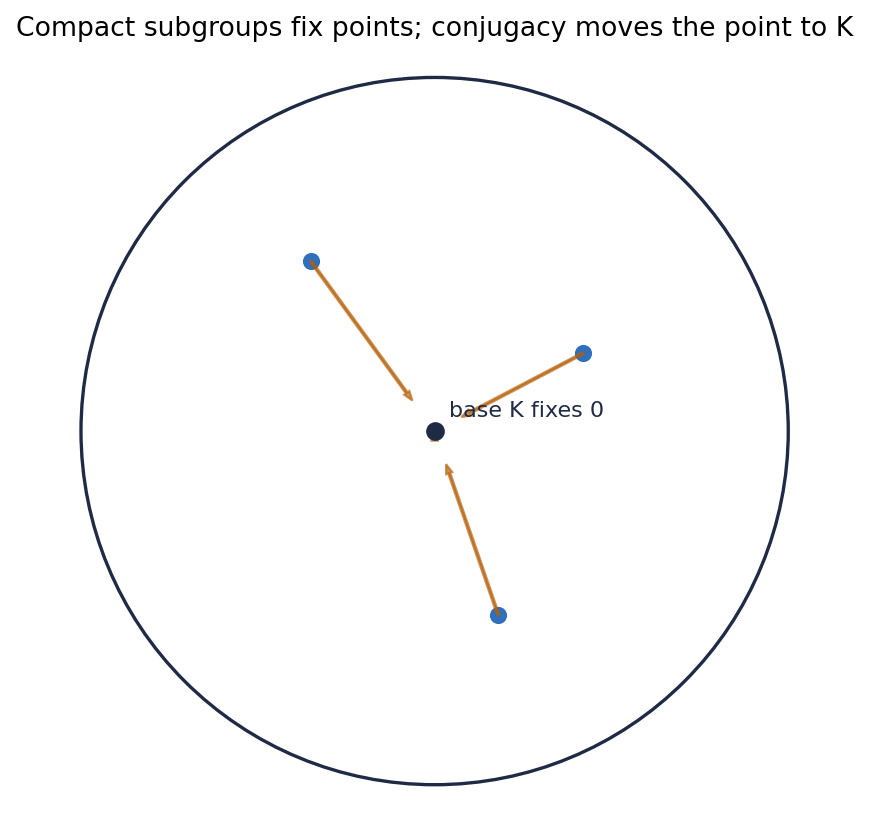

In [4]:
fixed_points = np.array([
    [0.0, 0.0],
    [0.42, 0.22],
    [-0.35, 0.48],
    [0.18, -0.52],
])

def disk_move_to_origin(a: complex, z: complex) -> complex:
    return (z - a) / (1 - np.conj(a) * z)

disk_rows = []
for x, y in fixed_points:
    a = complex(float(x), float(y))
    moved = disk_move_to_origin(a, a)
    disk_rows.append({
        "fixed_point": f"({x:.2f}, {y:.2f})",
        "inside_disk": bool(abs(a) < 1),
        "conjugated_to_origin_residual": float(abs(moved)),
    })

fig, ax = plt.subplots(figsize=(6.4, 6.2))
ax.add_patch(Circle((0, 0), 1, fill=False, color="#1f2a44", linewidth=1.5))
for x, y in fixed_points:
    ax.scatter([x], [y], color="#2f6fbb", s=45)
    ax.arrow(x, y, -0.82 * x, -0.82 * y, length_includes_head=True, color="#b45f06", alpha=0.65, width=0.006)
ax.scatter([0], [0], color="#1f2a44", s=55)
ax.text(0.04, 0.04, "base K fixes 0", color="#1f2a44")
ax.set_aspect("equal")
ax.set_xlim(-1.08, 1.08)
ax.set_ylim(-1.08, 1.08)
ax.set_title("Compact subgroups fix points; conjugacy moves the point to K")
ax.axis("off")
fixed_fig = record(save_matplotlib(fig, FIGURES / "maximal_compact_fixed_point_conjugacy.png"))
plt.close(fig)

fixed_table = record(save_csv(disk_rows, TABLES / "maximal_compact_fixed_point_conjugacy.csv"))
fixed_checks = {
    "all_sample_fixed_points_inside_disk": all(row["inside_disk"] for row in disk_rows),
    "disk_automorphisms_move_samples_to_origin": all(row["conjugated_to_origin_residual"] < 1e-12 for row in disk_rows),
}
fixed_report = record(save_json(fixed_checks, CHECKS / "maximal_compact_fixed_point_conjugacy_checks.json"))
chapter_checks["maximal_compact_fixed_point_model"] = all(fixed_checks.values())
print(json.dumps({"figure": rel(fixed_fig), "table": rel(fixed_table), "checks": rel(fixed_report)}, indent=2))
display_artifact(fixed_fig)


## 3. Iwasawa Decomposition in `SL(2,R)`

The Iwasawa decomposition refines Cartan coordinates into `K A N`. In `SL(2,R)`, `K` is rotation, `A` is diagonal stretch, and `N` is a unipotent horocycle group. The decomposition is the matrix version of Gram-Schmidt: each determinant-one matrix is reconstructed from angle, height, and horocycle coordinates.


{
  "figure": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/figures/sl2_iwasawa_upper_half_plane_coordinates.png",
  "table": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/sl2_iwasawa_kan_reconstruction.csv",
  "checks": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/sl2_iwasawa_checks.json"
}

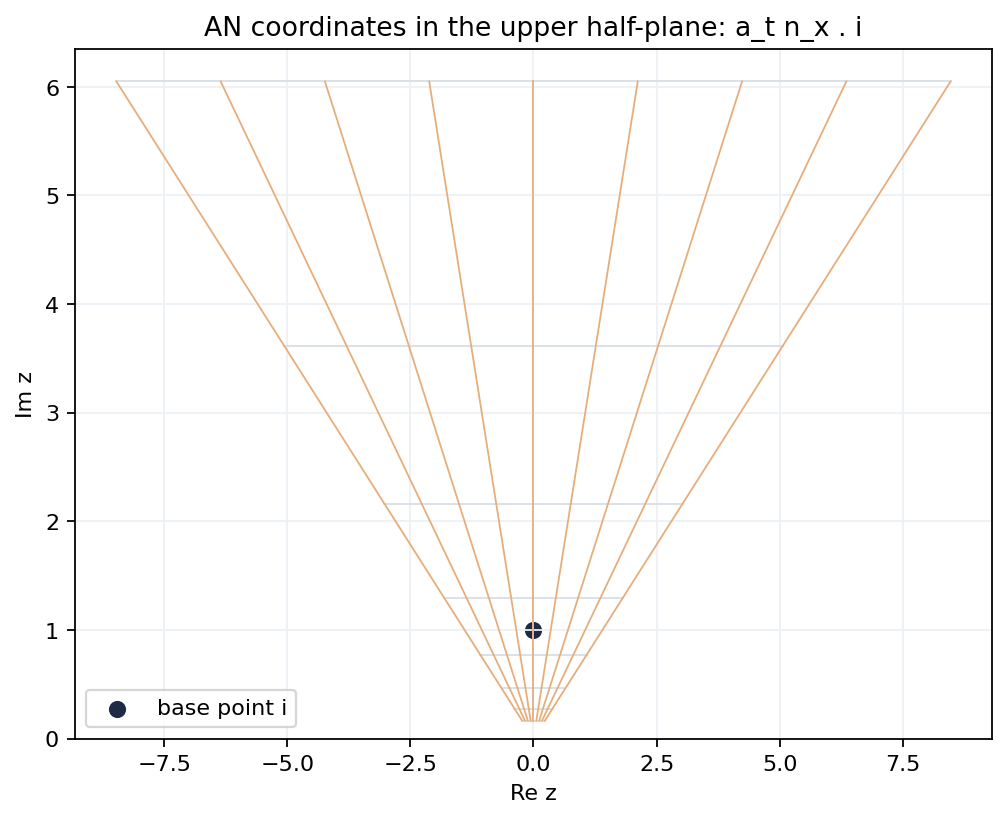

In [5]:
def kan_sl2(g: np.ndarray):
    a, b, c, d = g.ravel()
    r = math.hypot(a, c)
    k = np.array([[a / r, -c / r], [c / r, a / r]], dtype=float)
    avec = np.array([[r, 0.0], [0.0, 1.0 / r]], dtype=float)
    u = (a * b + c * d) / (r * r)
    n = np.array([[1.0, u], [0.0, 1.0]], dtype=float)
    return k, avec, n

samples = [
    np.array([[2.0, 1.0], [1.0, 1.0]]),
    np.array([[1.2, -0.4], [0.5, (1 + (-0.4) * 0.5) / 1.2]]),
    np.array([[0.8, 1.1], [-0.3, (1 + 1.1 * -0.3) / 0.8]]),
]
iwasawa_rows = []
for idx, g in enumerate(samples, start=1):
    k, a_mat, n_mat = kan_sl2(g)
    recon = k @ a_mat @ n_mat
    iwasawa_rows.append({
        "sample": idx,
        "det_g": round(float(np.linalg.det(g)), 12),
        "k_orthogonal_residual": float(np.linalg.norm(k.T @ k - np.eye(2))),
        "a_positive_diagonal": bool(a_mat[0, 0] > 0 and a_mat[1, 1] > 0),
        "n_unipotent": bool(abs(n_mat[0, 0] - 1) < 1e-12 and abs(n_mat[1, 1] - 1) < 1e-12),
        "reconstruction_residual": float(np.linalg.norm(recon - g)),
    })
iwasawa_table = record(save_csv(iwasawa_rows, TABLES / "sl2_iwasawa_kan_reconstruction.csv"))

t_vals = np.linspace(-0.9, 0.9, 8)
x_vals = np.linspace(-1.4, 1.4, 9)
fig, ax = plt.subplots(figsize=(7.4, 5.6))
for t in t_vals:
    y = math.exp(2 * t)
    xs = np.exp(2 * t) * x_vals
    ax.plot(xs, np.full_like(xs, y), color="#d7dee7", linewidth=0.8)
for x in x_vals:
    pts = np.array([(math.exp(2 * t) * x, math.exp(2 * t)) for t in t_vals])
    ax.plot(pts[:, 0], pts[:, 1], color="#e6ad79", linewidth=0.8)
ax.scatter([0], [1], color="#1f2a44", s=45, label="base point i")
ax.set_title("AN coordinates in the upper half-plane: a_t n_x . i")
ax.set_xlabel("Re z")
ax.set_ylabel("Im z")
ax.set_ylim(0, max(math.exp(2 * t) for t in t_vals) * 1.05)
ax.grid(True, color="#edf1f5")
ax.legend()
iwasawa_fig = record(save_matplotlib(fig, FIGURES / "sl2_iwasawa_upper_half_plane_coordinates.png"))
plt.close(fig)

iwasawa_checks = {
    "lie_algebra_direct_sum_basis": bool(sp.Matrix.hstack(K.reshape(4, 1), H.reshape(4, 1), E.reshape(4, 1)).rank() == 3),
    "a_normalizes_n": bool(comm(H, E) == 2 * E),
    "n_is_nilpotent_in_sl2": bool(comm(E, E) == sp.zeros(2)),
    "all_kan_reconstructions_small": all(row["reconstruction_residual"] < 1e-10 for row in iwasawa_rows),
}
iwasawa_report = record(save_json(iwasawa_checks, CHECKS / "sl2_iwasawa_checks.json"))
chapter_checks["sl2_iwasawa_decomposition_checks"] = all(iwasawa_checks.values())
print(json.dumps({"figure": rel(iwasawa_fig), "table": rel(iwasawa_table), "checks": rel(iwasawa_report)}, indent=2))
display_artifact(iwasawa_fig)


## 4. Restricted Roots and the Nilpotent Algebra `n`

For split `sl(3,R)`, choose `a` as diagonal trace-zero matrices. The positive restricted roots are `e1-e2`, `e2-e3`, and `e1-e3`; their root spaces are the upper triangular elementary matrices. Their sum is the nilpotent algebra `n`, and its central descending series terminates quickly.


{
  "figure": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/figures/sl3_restricted_roots_and_nilpotent_n.png",
  "table": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/sl3_restricted_root_spaces.csv",
  "checks": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/sl3_restricted_root_nilpotent_checks.json"
}


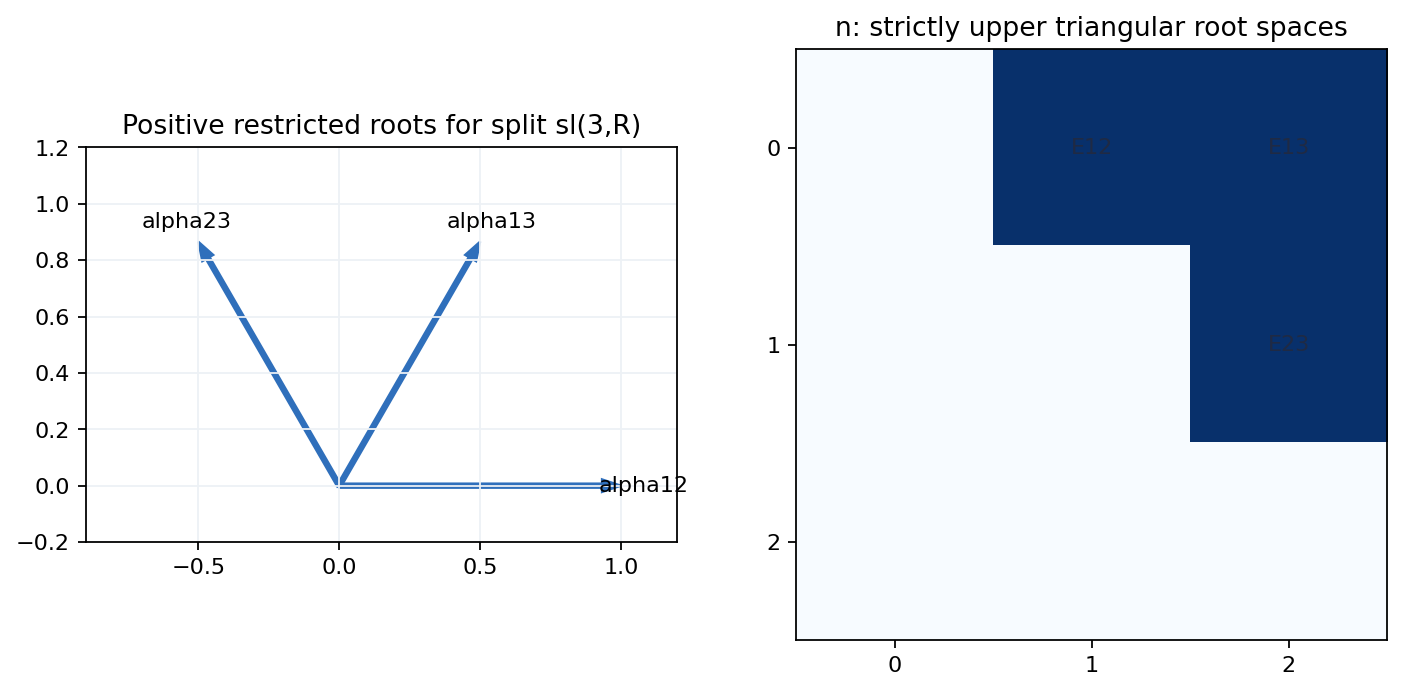

In [6]:
def Eij(i, j, n=3):
    M = sp.zeros(n)
    M[i, j] = 1
    return M

H12 = sp.diag(1, -1, 0)
H23 = sp.diag(0, 1, -1)
E12 = Eij(0, 1)
E23 = Eij(1, 2)
E13 = Eij(0, 2)
root_mats = {"alpha12": E12, "alpha23": E23, "alpha13": E13}
root_coords = {"alpha12": (1, 0), "alpha23": (-0.5, math.sqrt(3) / 2), "alpha13": (0.5, math.sqrt(3) / 2)}

root_rows = []
for name, M in root_mats.items():
    root_rows.append({
        "root": name,
        "[H12,E] multiple": str(comm(H12, M)),
        "[H23,E] multiple": str(comm(H23, M)),
        "strictly_upper_triangular": bool(all(M[i, j] == 0 for i in range(3) for j in range(i + 1))),
    })
root_table = record(save_csv(root_rows, TABLES / "sl3_restricted_root_spaces.csv"))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
for name, (x, y) in root_coords.items():
    axes[0].arrow(0, 0, x, y, color="#2f6fbb", width=0.015, length_includes_head=True)
    axes[0].text(x * 1.08, y * 1.08, name, ha="center", va="center")
axes[0].set_title("Positive restricted roots for split sl(3,R)")
axes[0].set_aspect("equal")
axes[0].grid(True, color="#edf1f5")
axes[0].set_xlim(-0.9, 1.2)
axes[0].set_ylim(-0.2, 1.2)
tri = np.array([[0, 1, 1], [0, 0, 1], [0, 0, 0]])
axes[1].imshow(tri, cmap="Blues", vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        label = "" if tri[i, j] == 0 else f"E{i+1}{j+1}"
        axes[1].text(j, i, label, ha="center", va="center", color="#1f2a44")
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))
axes[1].set_title("n: strictly upper triangular root spaces")
root_fig = record(save_matplotlib(fig, FIGURES / "sl3_restricted_roots_and_nilpotent_n.png"))
plt.close(fig)

first_comm = [comm(A, B) for A in root_mats.values() for B in root_mats.values()]
derived1_dim = len([C for C in first_comm if C != sp.zeros(3)])
derived2 = [comm(E13, M) for M in root_mats.values()]
root_checks = {
    "E12_E23_brackets_to_E13": bool(comm(E12, E23) == E13),
    "E12_E13_bracket_zero": bool(comm(E12, E13) == sp.zeros(3)),
    "E23_E13_bracket_zero": bool(comm(E23, E13) == sp.zeros(3)),
    "central_descending_dimensions": [3, 1, 0],
    "nilpotent_series_terminates": bool(all(C == sp.zeros(3) for C in derived2)),
}
root_report = record(save_json(root_checks, CHECKS / "sl3_restricted_root_nilpotent_checks.json"))
chapter_checks["sl3_restricted_root_nilpotent_checks"] = bool(root_checks["E12_E23_brackets_to_E13"] and root_checks["nilpotent_series_terminates"])
print(json.dumps({"figure": rel(root_fig), "table": rel(root_table), "checks": rel(root_report)}, indent=2))
display_artifact(root_fig)


## 5. Nilpotent Groups Have Polynomial Exponential Coordinates

Section 4 proves that nilpotent Lie groups multiply by a polynomial law in exponential coordinates. The Heisenberg group is the cleanest witness: the only correction term is central and equals half the signed area made by the horizontal coordinates.


{
  "figure": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/figures/heisenberg_bch_central_area.png",
  "table": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/heisenberg_bch_samples.csv",
  "checks": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/heisenberg_bch_polynomial_checks.json"
}


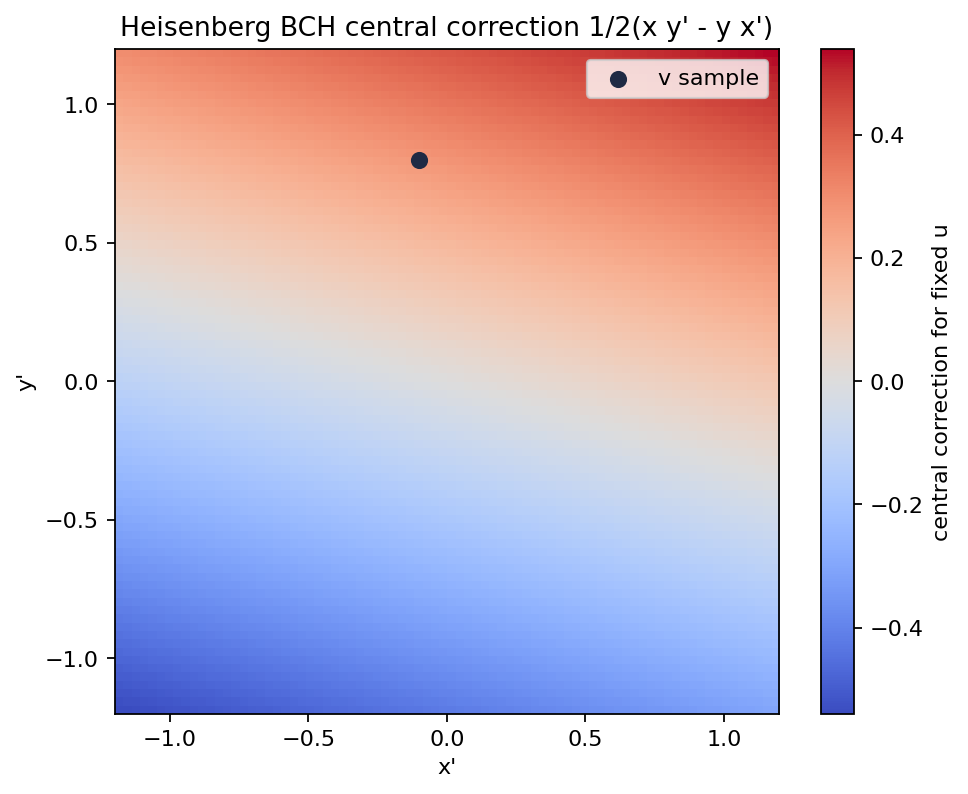

In [7]:
def heis_mul(u, v):
    x, y, z = u
    xp, yp, zp = v
    return np.array([x + xp, y + yp, z + zp + 0.5 * (x * yp - y * xp)], dtype=float)

u0 = np.array([0.7, -0.2, 0.4])
v0 = np.array([-0.1, 0.8, -0.3])
w0 = np.array([0.3, 0.25, 0.1])
left_assoc = heis_mul(heis_mul(u0, v0), w0)
right_assoc = heis_mul(u0, heis_mul(v0, w0))

xs = np.linspace(-1.2, 1.2, 80)
ys = np.linspace(-1.2, 1.2, 80)
Xg, Yg = np.meshgrid(xs, ys)
central = 0.5 * (u0[0] * Yg - u0[1] * Xg)

fig, ax = plt.subplots(figsize=(6.7, 5.4))
im = ax.imshow(central, extent=[xs.min(), xs.max(), ys.min(), ys.max()], origin="lower", cmap="coolwarm")
ax.scatter([v0[0]], [v0[1]], color="#1f2a44", s=45, label="v sample")
ax.set_title("Heisenberg BCH central correction 1/2(x y' - y x')")
ax.set_xlabel("x'")
ax.set_ylabel("y'")
fig.colorbar(im, ax=ax, label="central correction for fixed u")
ax.legend()
heis_fig = record(save_matplotlib(fig, FIGURES / "heisenberg_bch_central_area.png"))
plt.close(fig)

heis_rows = [
    {"input": "u", "x": u0[0], "y": u0[1], "z": u0[2]},
    {"input": "v", "x": v0[0], "y": v0[1], "z": v0[2]},
    {"input": "u*v", "x": heis_mul(u0, v0)[0], "y": heis_mul(u0, v0)[1], "z": heis_mul(u0, v0)[2]},
]
heis_table = record(save_csv(heis_rows, TABLES / "heisenberg_bch_samples.csv"))
heis_checks = {
    "associativity_sample_residual": float(np.linalg.norm(left_assoc - right_assoc)),
    "central_correction_is_polynomial": True,
    "commutator_is_central": bool(np.allclose(heis_mul(u0, v0)[:2] - heis_mul(v0, u0)[:2], [0, 0])),
}
heis_report = record(save_json(heis_checks, CHECKS / "heisenberg_bch_polynomial_checks.json"))
chapter_checks["heisenberg_bch_polynomial_checks"] = heis_checks["associativity_sample_residual"] < 1e-12 and heis_checks["commutator_is_central"]
print(json.dumps({"figure": rel(heis_fig), "table": rel(heis_table), "checks": rel(heis_report)}, indent=2))
display_artifact(heis_fig)


## 6. Global `KAN` and the Solvable Model `AN`

The global theorem says `K x A x N -> G` is an analytic diffeomorphism. The solvable group `S = AN` is closed and parametrizes the symmetric space. In `SL(2,R)`, the map `s -> theta(s)s^-1` lands in the positive symmetric determinant-one matrices `P = exp(p0)`.


{
  "figure": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/figures/an_to_positive_symmetric_matrices.png",
  "table": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/an_to_positive_symmetric_samples.csv",
  "checks": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/an_to_positive_symmetric_checks.json"
}


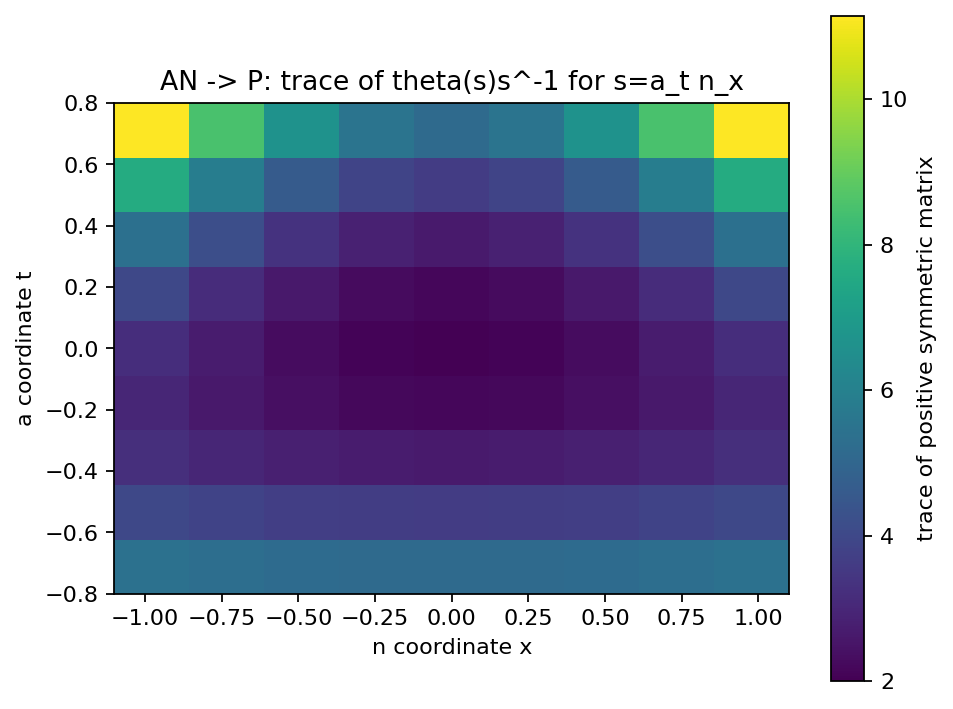

In [8]:
def A_t(t):
    return np.array([[math.exp(t), 0.0], [0.0, math.exp(-t)]], dtype=float)

def N_x(x):
    return np.array([[1.0, x], [0.0, 1.0]], dtype=float)

def theta_group(g):
    return np.linalg.inv(g).T

an_rows = []
trace_grid = []
for t in np.linspace(-0.8, 0.8, 9):
    row = []
    for x in np.linspace(-1.1, 1.1, 9):
        s = A_t(float(t)) @ N_x(float(x))
        pmat = theta_group(s) @ np.linalg.inv(s)
        eigs = np.linalg.eigvalsh(pmat)
        row.append(np.trace(pmat))
        an_rows.append({
            "t": round(float(t), 4),
            "x": round(float(x), 4),
            "symmetric_residual": float(np.linalg.norm(pmat - pmat.T)),
            "determinant": round(float(np.linalg.det(pmat)), 12),
            "min_eigenvalue": float(eigs.min()),
        })
    trace_grid.append(row)
trace_grid = np.array(trace_grid)
an_table = record(save_csv(an_rows[:12], TABLES / "an_to_positive_symmetric_samples.csv"))

fig, ax = plt.subplots(figsize=(6.8, 5.4))
im = ax.imshow(trace_grid, origin="lower", extent=[-1.1, 1.1, -0.8, 0.8], cmap="viridis")
ax.set_title("AN -> P: trace of theta(s)s^-1 for s=a_t n_x")
ax.set_xlabel("n coordinate x")
ax.set_ylabel("a coordinate t")
fig.colorbar(im, ax=ax, label="trace of positive symmetric matrix")
an_fig = record(save_matplotlib(fig, FIGURES / "an_to_positive_symmetric_matrices.png"))
plt.close(fig)

an_checks = {
    "all_symmetric_residuals_small": all(row["symmetric_residual"] < 1e-10 for row in an_rows),
    "all_determinants_one": all(abs(row["determinant"] - 1.0) < 1e-10 for row in an_rows),
    "all_positive_eigenvalues": all(row["min_eigenvalue"] > 0 for row in an_rows),
}
an_report = record(save_json(an_checks, CHECKS / "an_to_positive_symmetric_checks.json"))
chapter_checks["an_to_positive_symmetric_checks"] = all(an_checks.values())
print(json.dumps({"figure": rel(an_fig), "table": rel(an_table), "checks": rel(an_report)}, indent=2))
display_artifact(an_fig)


## 7. The Complex Case

When a complex semisimple Lie algebra is regarded as a real Lie algebra, the Iwasawa decomposition becomes `g_R = u + J a + n+`. For `sl(2,C)_R`, the compact real form is `su(2)` with real dimension `3`; `J a` has real dimension `1`; and the positive complex root space contributes real dimension `2`. This is the smallest example of the restricted-root multiplicity doubling noted in the exercises.


{
  "figure": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/figures/complex_case_root_multiplicity.png",
  "table": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/complex_case_sl2c_iwasawa_dimensions.csv",
  "checks": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/complex_case_iwasawa_checks.json"
}


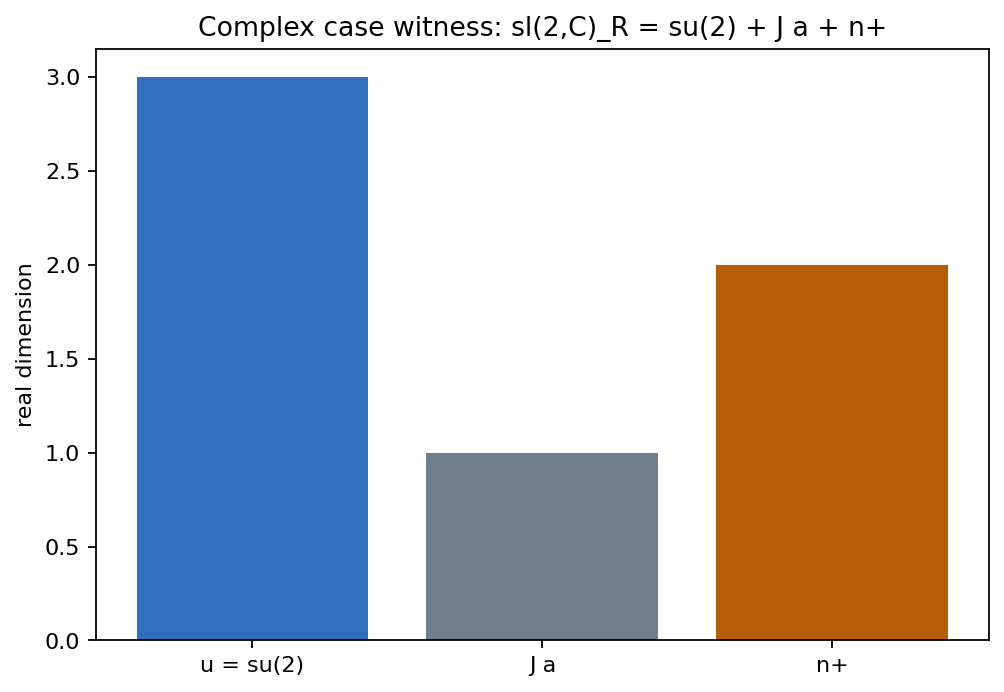

In [9]:
complex_rows = [
    {"piece": "u = su(2)", "real_dimension": 3, "role": "compact real form"},
    {"piece": "J a", "real_dimension": 1, "role": "abelian A direction"},
    {"piece": "n+", "real_dimension": 2, "role": "positive complex root space as real space"},
]
complex_table = record(save_csv(complex_rows, TABLES / "complex_case_sl2c_iwasawa_dimensions.csv"))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.bar([row["piece"] for row in complex_rows], [row["real_dimension"] for row in complex_rows], color=["#2f6fbb", "#6f7d8c", "#b45f06"])
ax.set_ylabel("real dimension")
ax.set_title("Complex case witness: sl(2,C)_R = su(2) + J a + n+")
complex_fig = record(save_matplotlib(fig, FIGURES / "complex_case_root_multiplicity.png"))
plt.close(fig)

complex_checks = {
    "dimensions_sum_to_sl2c_real_dimension": sum(row["real_dimension"] for row in complex_rows) == 6,
    "positive_root_real_multiplicity_two": complex_rows[2]["real_dimension"] == 2,
    "abelian_direction_dimension_one": complex_rows[1]["real_dimension"] == 1,
}
complex_report = record(save_json(complex_checks, CHECKS / "complex_case_iwasawa_checks.json"))
chapter_checks["complex_case_dimension_checks"] = all(complex_checks.values())
print(json.dumps({"figure": rel(complex_fig), "table": rel(complex_table), "checks": rel(complex_report)}, indent=2))
display_artifact(complex_fig)


## Applied Lab: Decompose a Matrix, Then Move the Base Point

Pick a determinant-one real matrix `g`. The `KAN` decomposition separates it into rotation, stretch, and horocycle pieces. Acting on the base point `i`, the `K` part only changes the frame; the `AN` part supplies coordinates for the point in `G/K`. This lab table lets you compare the reconstruction residual with the image point in the upper half-plane.


In [10]:
lab_rows = []
for idx, g in enumerate(samples, start=1):
    k, a_mat, n_mat = kan_sl2(g)
    z_g = mobius(g, 1j)
    z_an = mobius(a_mat @ n_mat, 1j)
    lab_rows.append({
        "sample": idx,
        "g.i": f"{z_g.real:.6f}+{z_g.imag:.6f}i",
        "AN.i": f"{z_an.real:.6f}+{z_an.imag:.6f}i",
        "KAN_reconstruction_residual": float(np.linalg.norm(k @ a_mat @ n_mat - g)),
        "AN_height_positive": bool(z_an.imag > 0),
    })
lab_table = record(save_csv(lab_rows, TABLES / "kan_matrix_decomposition_lab.csv"))
lab_checks = {
    "all_lab_reconstructions_small": all(row["KAN_reconstruction_residual"] < 1e-10 for row in lab_rows),
    "all_an_heights_positive": all(row["AN_height_positive"] for row in lab_rows),
}
lab_report = record(save_json(lab_checks, CHECKS / "kan_matrix_decomposition_lab_checks.json"))
chapter_checks["kan_matrix_lab_checks"] = all(lab_checks.values())
print(json.dumps({"table": rel(lab_table), "checks": rel(lab_report)}, indent=2))
display_artifact(lab_table)


{
  "table": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/kan_matrix_decomposition_lab.csv",
  "checks": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/kan_matrix_decomposition_lab_checks.json"
}


[kan_matrix_decomposition_lab.csv](artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/tables/kan_matrix_decomposition_lab.csv)

## Takeaways

- Noncompact symmetric spaces have global linear coordinates: `p0` maps diffeomorphically onto `G/K`.
- Maximal compact subgroups are geometric isotropy groups at fixed points, and all such choices are conjugate.
- Iwasawa decomposition `G = KAN` refines the geometry into angular, flat, and nilpotent directions.
- The nilpotent group `N` is not mysterious in coordinates: its exponential multiplication is polynomial.
- The solvable group `AN` gives a concrete model of the symmetric space, while the complex case packages the same idea with doubled real root multiplicities.


In [11]:
def json_scalar(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if hasattr(value, "item"):
        try:
            return value.item()
        except Exception:
            return value
    return value

chapter_checks_json = {name: json_scalar(value) for name, value in chapter_checks.items()}
final_sanity = {
    "chapter": "Chapter VI. Symmetric Spaces of the Noncompact Type",
    "source_span": "printed pages 252-280, approximately PDF pages 279-307",
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": chapter_checks_json,
    "coverage_note": "Sections 1-6 are represented by Cartan/Exp coordinates, maximal compact fixed-point geometry, Iwasawa KAN reconstruction, restricted-root nilpotent checks, nilpotent BCH, AN-to-P global coordinates, and the complex-case dimension split.",
}
failed = [name for name, value in chapter_checks_json.items() if isinstance(value, bool) and not value]
if failed:
    raise AssertionError(f"Chapter sanity checks failed: {failed}")
final_sanity_path = record(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(artifact_paths, min_bytes=64)
assert_artifacts([final_sanity_path], min_bytes=64)
print(json.dumps({"final_sanity": rel(final_sanity_path), "boolean_checks": len([v for v in chapter_checks_json.values() if isinstance(v, bool)]), "failed": failed}, indent=2))
display_artifact(final_sanity_path)


{
  "final_sanity": "artifacts/chapter-06-symmetric-spaces-of-the-noncompact-type/checks/final_sanity.json",
  "boolean_checks": 9,
  "failed": []
}


`final_sanity.json`